Importaing all packages

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.decomposition import PCA

Viewing high view of dataset

In [17]:
df = pd.read_csv("../data/creditcard.csv")

df.head()
df.info()
df.describe()
df["Class"].value_counts()

#0 -> normal transaction
#1 -> fraud

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Class
0    284315
1       492
Name: count, dtype: int64

Plotting pie graph of fradulent vs normal transations (saved to /figures)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


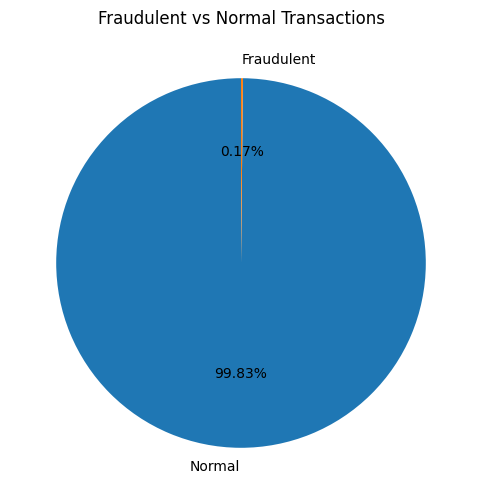

In [18]:
fraud_counts = df["Class"].value_counts()

labels = ["Normal", "Fraudulent"]
sizes = fraud_counts.values

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Fraudulent vs Normal Transactions")

plt.savefig(
    "../figures/class_distribution_pie.png",
    bbox_inches="tight"
)

counts = df["Class"].value_counts()
percentages = df["Class"].value_counts(normalize=True) * 100

#Counts and percentages of transaction types
print(counts)
print(percentages)

plt.show()

In [19]:
X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (227845, 30)
X_test: (56962, 30)
y_train distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
y_test distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [21]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:, 1]

In [26]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = []

results.append(evaluate_model("Logistic Regression", y_test, log_preds, log_probs))
results.append(evaluate_model("Random Forest", y_test, rf_preds, rf_probs))
results.append(evaluate_model("Gradient Boosting", y_test, gb_preds, gb_probs))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.975475,0.060852,0.918367,0.114141,0.972167
1,Random Forest,0.999403,0.826531,0.826531,0.826531,0.976570
2,Gradient Boosting,0.998736,0.680556,0.500000,0.576471,0.597462


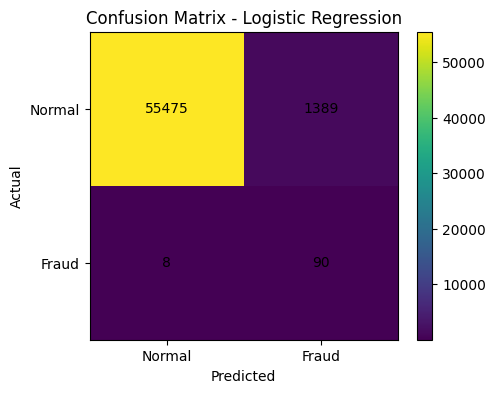

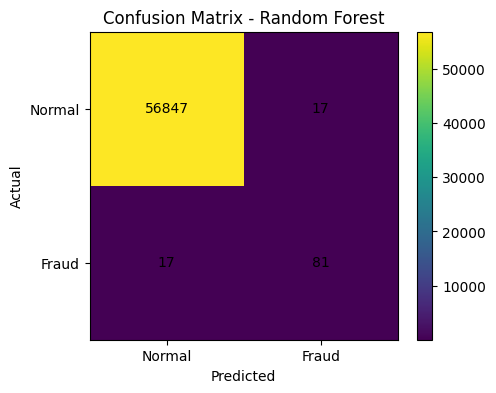

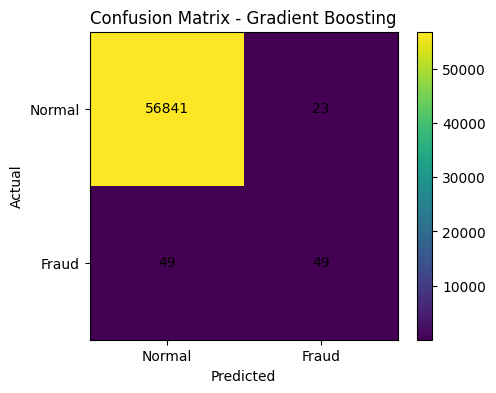

In [32]:
model_pr = {
    "Logistic Regression": log_probs,
    "Random Forest": rf_probs,
    "Gradient Boosting": gb_probs
}

for name, preds in model_predictions.items():
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xticks([0,1], ["Normal", "Fraud"])
    plt.yticks([0,1], ["Normal", "Fraud"])
    plt.show()

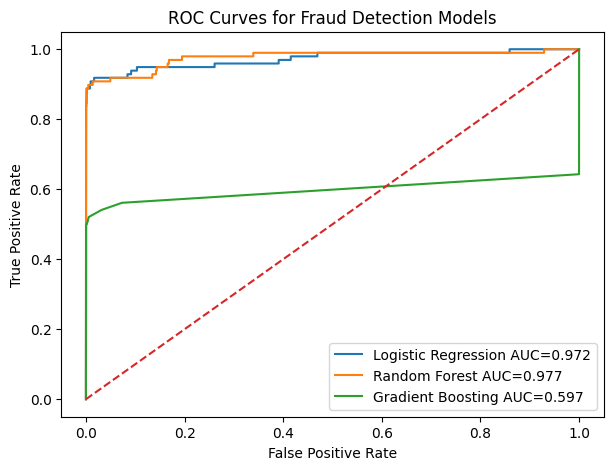

In [33]:
model_probs = {
    "Logistic Regression": log_probs,
    "Random Forest": rf_probs,
    "Gradient Boosting": gb_probs
}

plt.figure(figsize=(7,5))

for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Fraud Detection Models")
plt.legend()
plt.show()

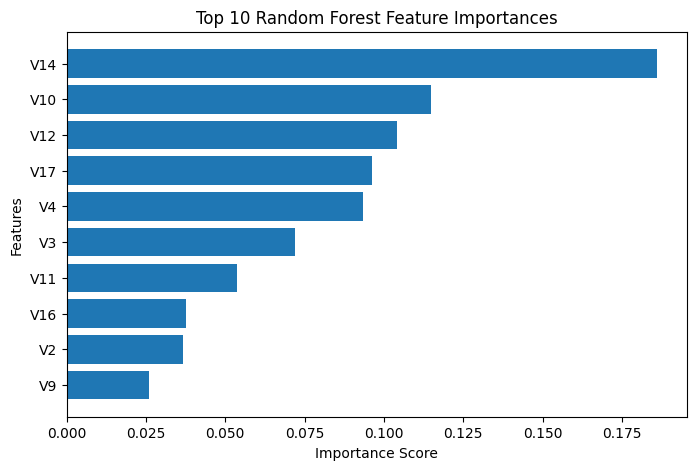

In [34]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

feature_importance_df

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

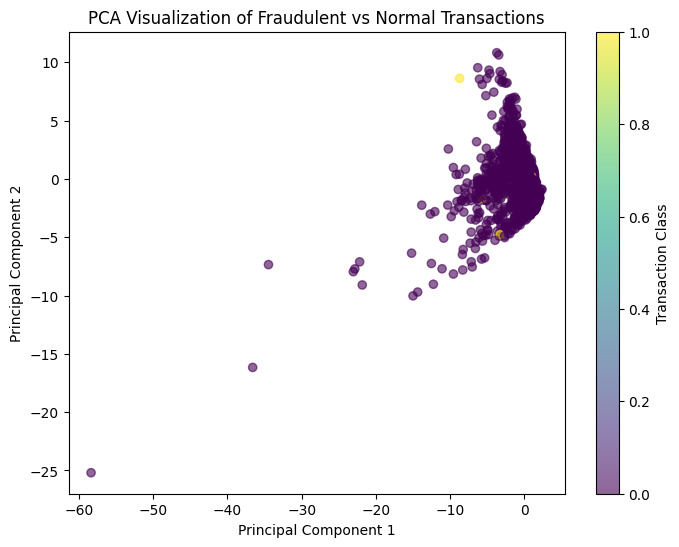

In [35]:
# Create a smaller sample for visualization
sample_df = df.sample(5000, random_state=42)

# Separate features and labels
X_sample = sample_df.drop("Class", axis=1)
y_sample = sample_df["Class"]

# Scale Time and Amount columns
sample_scaler = StandardScaler()

X_sample[["Time", "Amount"]] = sample_scaler.fit_transform(
    X_sample[["Time", "Amount"]]
)

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

# Plot PCA visualization
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_sample,
    alpha=0.6
)

plt.title("PCA Visualization of Fraudulent vs Normal Transactions")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Transaction Class")

plt.show()